In [ ]:
%pip install torch numpy pretty_midi matplotlib scikit-learn

In [ ]:
import torch
import numpy as np
import random
import os, sys

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

if torch.cuda.is_available():
    device = torch.device("cuda")
    print("Using CUDA GPU.")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
    print("Using Apple Silicon GPU (MPS).")
else:
    device = torch.device("cpu")
    print("Using CPU.")

PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

Using Apple Silicon GPU (MPS).


## 1. Load Processed Data
Load X, y, vocabulary, and train/validation/test indices created during preprocessing.

In [ ]:
from pathlib import Path
import numpy as np

BASE_DIR = Path.cwd().parent

DATA_PATH = BASE_DIR / "data" / "processed" / "full_sequences.npz"
data = np.load(DATA_PATH, allow_pickle=True)

X_ids = data["X"]
y_ids = data["y"]
vocab = data["vocab"]
SEQ_LEN = data["seq_len"]

print("Loaded dataset from:", DATA_PATH)
print("  X_ids shape:", X_ids.shape)
print("  y_ids shape:", y_ids.shape)
print("  vocab size:", vocab.shape[0])
print("  SEQ_LEN:", SEQ_LEN)

Loaded dataset from: /Users/catherinembata/music-generation-project/data/processed/full_sequences.npz
  X_ids shape: (773541, 50)
  y_ids shape: (773541,)
  vocab size: 307
  SEQ_LEN: 50


In [3]:
SPLITS_PATH = BASE_DIR / "data" / "processed" / "splits_filelevel_indices.npz"
splits = np.load(SPLITS_PATH)

train_idx = splits["train_idx"]
val_idx   = splits["val_idx"]
test_idx  = splits["test_idx"]

print("Loaded splits from:", SPLITS_PATH)
print("  Train examples:", len(train_idx))
print("  Val examples:  ", len(val_idx))
print("  Test examples: ", len(test_idx))

Loaded splits from: /Users/catherinembata/music-generation-project/data/processed/splits_filelevel_indices.npz
  Train examples: 544255
  Val examples:   100285
  Test examples:  129001


## 2. Dataset and DataLoaders
Wrap the sequences into a PyTorch Dataset and build DataLoaders with batching and shuffling.


In [ ]:
from torch.utils.data import Dataset, DataLoader

print("Using device:", device)

class MusicSequenceDataset(Dataset):
    """
    Wraps X_ids and y_ids, but only exposes the rows given by index_array.
    Each __getitem__ returns (input_seq, target_token) as torch tensors.
    """
    def __init__(self, X_all, y_all, index_array):
        self.X_all = X_all
        self.y_all = y_all
        self.index_array = index_array

    def __len__(self):
        return len(self.index_array)

    def __getitem__(self, idx):
        real_idx = self.index_array[idx]
        x = self.X_all[real_idx] 
        y = self.y_all[real_idx]

        x = torch.tensor(x, dtype=torch.long)
        y = torch.tensor(y, dtype=torch.long)
        return x, y

BATCH_SIZE = 128

train_dataset = MusicSequenceDataset(X_ids, y_ids, train_idx)
val_dataset   = MusicSequenceDataset(X_ids, y_ids, val_idx)
test_dataset  = MusicSequenceDataset(X_ids, y_ids, test_idx)

print("Train dataset size:", len(train_dataset))
print("Val dataset size:  ", len(val_dataset))
print("Test dataset size: ", len(test_dataset))

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    drop_last=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    drop_last=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    drop_last=False
)

batch_x, batch_y = next(iter(train_loader))
print("One batch X shape:", batch_x.shape)
print("One batch y shape:", batch_y.shape)
print("X dtype:", batch_x.dtype, "| y dtype:", batch_y.dtype)

Using device: mps
Train dataset size: 544255
Val dataset size:   100285
Test dataset size:  129001
One batch X shape: torch.Size([128, 50])
One batch y shape: torch.Size([128])
X dtype: torch.int64 | y dtype: torch.int64


## 3. Baseline Models (Most Frequent Token and Repeat Previous Token)
As a reference point, compute the accuracy of two simple baselines: a majority token predictor that always chooses the most common next token, and a repeat previous token model that copies the last note in the sequence. These baselines establish the minimal performance the GRU should surpass.

In [ ]:
import numpy as np

y_train = y_ids[train_idx]
y_val   = y_ids[val_idx]
y_test  = y_ids[test_idx]

def majority_baseline_accuracy(y, majority_id):
    return np.mean(y == majority_id)

def last_token_baseline_accuracy(y):
    if len(y) <= 1:
        return 0.0
    y_true = y[1:]
    y_pred = y[:-1]  
    return np.mean(y_true == y_pred)

(unique, counts) = np.unique(y_train, return_counts=True)
majority_token_id = unique[np.argmax(counts)]
majority_count = counts.max()

print("Majority token ID (from train):", majority_token_id)
print("Appears in train labels:", majority_count, "times")

baseline_train_acc = majority_baseline_accuracy(y_train, majority_token_id)
baseline_val_acc   = majority_baseline_accuracy(y_val, majority_token_id)
baseline_test_acc  = majority_baseline_accuracy(y_test, majority_token_id)

print("\nMajority-token baseline accuracy:")
print(f"  Train: {baseline_train_acc:.4f}")
print(f"  Val:   {baseline_val_acc:.4f}")
print(f"  Test:  {baseline_test_acc:.4f}")

last_train_acc = last_token_baseline_accuracy(y_train)
last_val_acc   = last_token_baseline_accuracy(y_val)
last_test_acc  = last_token_baseline_accuracy(y_test)

print("\nLast-token baseline accuracy:")
print(f"  Train: {last_train_acc:.4f}")
print(f"  Val:   {last_val_acc:.4f}")
print(f"  Test:  {last_test_acc:.4f}")


Majority token ID (from train): 8
Appears in train labels: 19887 times

Majority-token baseline accuracy:
  Train: 0.0365
  Val:   0.0333
  Test:  0.0400

Last-token baseline accuracy:
  Train: 0.0331
  Val:   0.0344
  Test:  0.0415


## 4. Define GRU Model (Custom Architecture)
Import the model class and create the GRU instance using saved hyperparameters.

In [6]:
import torch.nn as nn
from pathlib import Path
import sys

VOCAB_SIZE = vocab.shape[0]
SEQ_LEN = X_ids.shape[1]
print("VOCAB_SIZE:", VOCAB_SIZE, "| SEQ_LEN:", SEQ_LEN)

from src.model import MusicGRUModel

model = MusicGRUModel(
    vocab_size=VOCAB_SIZE,
    embed_dim=64,
    hidden_dim=192,
    num_layers=1,
    dropout=0.3,
).to(device)

print(model)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-3,
    weight_decay=1e-5,
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,
    patience=2,
)

num_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print("Number of trainable parameters:", num_params)

VOCAB_SIZE: 307 | SEQ_LEN: 50
MusicGRUModel(
  (embedding): Embedding(307, 64)
  (gru): GRU(64, 192, batch_first=True)
  (dropout_layer): Dropout(p=0.3, inplace=False)
  (fc): Linear(in_features=192, out_features=307, bias=True)
)
Number of trainable parameters: 227507


## 5. Training Loop (GPU-Accelerated)
Train the GRU model using MPS/Apple Silicon GPU acceleration and measure accuracy/loss.

In [ ]:
import math
import time

NUM_EPOCHS = 10
PRINT_EVERY = 1

train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

best_val_loss = float("inf")
best_state_dict = None  
patience = 4         # stop after 4 epochs with no improvement
patience_counter = 0


def run_epoch(loader, model, criterion, optimizer=None):
    """
    Run one epoch.
    If optimizer is provided -> training mode (backprop).
    If optimizer is None      -> evaluation mode (no grad).
    Returns (avg_loss, accuracy).
    """
    if optimizer is None:
        model.eval()
    else:
        model.train()

    total_loss = 0.0
    total_correct = 0
    total_examples = 0

    for batch_x, batch_y in loader:
        batch_x = batch_x.to(device)
        batch_y = batch_y.to(device)

        if optimizer is not None:
            optimizer.zero_grad()

        logits = model(batch_x)
        loss = criterion(logits, batch_y)

        if optimizer is not None:
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
            optimizer.step()

        total_loss += loss.item() * batch_x.size(0)

        preds = torch.argmax(logits, dim=1)
        correct = (preds == batch_y).sum().item()
        total_correct += correct
        total_examples += batch_x.size(0)

    avg_loss = total_loss / total_examples
    accuracy = total_correct / total_examples
    perplexity = math.exp(avg_loss)

    return avg_loss, accuracy, perplexity

for epoch in range(1, NUM_EPOCHS + 1):
    start_time = time.time()

    train_loss, train_acc, train_ppl = run_epoch(
        train_loader, model, criterion, optimizer=optimizer
    )

    with torch.no_grad():
        val_loss, val_acc, val_ppl = run_epoch(
            val_loader, model, criterion, optimizer=None
        )

    scheduler.step(val_loss)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accuracies.append(train_acc)
    val_accuracies.append(val_acc)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_state_dict = model.state_dict()
        patience_counter = 0
        print(f"  New best model at epoch {epoch} (val_loss={val_loss:.4f})")
    
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"Early stopping at epoch {epoch}. No improvement in {patience} epochs.")
            break

    elapsed = time.time() - start_time

    if epoch % PRINT_EVERY == 0:
        print(
            f"Epoch {epoch:02d}/{NUM_EPOCHS} "
            f"- {elapsed:.1f}s | "
            f"train_loss: {train_loss:.4f}, train_acc: {train_acc:.4f}, perplexity: {train_ppl:.4f} | "
            f"val_loss: {val_loss:.4f}, val_acc: {val_acc:.4f}, val_perplexity: {val_ppl:.4f}"
        )

print("Training complete.")
print("Best validation loss:", best_val_loss)

  New best model at epoch 1 (val_loss=3.1308)
Epoch 01/10 - 82.6s | train_loss: 3.2977, train_acc: 0.1890, perplexity: 27.0512 | val_loss: 3.1308, val_acc: 0.2119, val_perplexity: 22.8912
  New best model at epoch 2 (val_loss=3.0458)
Epoch 02/10 - 86.3s | train_loss: 3.0237, train_acc: 0.2356, perplexity: 20.5681 | val_loss: 3.0458, val_acc: 0.2284, val_perplexity: 21.0268
  New best model at epoch 3 (val_loss=2.9976)
Epoch 03/10 - 88.6s | train_loss: 2.9377, train_acc: 0.2530, perplexity: 18.8727 | val_loss: 2.9976, val_acc: 0.2399, val_perplexity: 20.0376
  New best model at epoch 4 (val_loss=2.9727)
Epoch 04/10 - 85.4s | train_loss: 2.8825, train_acc: 0.2651, perplexity: 17.8587 | val_loss: 2.9727, val_acc: 0.2454, val_perplexity: 19.5441
  New best model at epoch 5 (val_loss=2.9568)
Epoch 05/10 - 89.0s | train_loss: 2.8399, train_acc: 0.2735, perplexity: 17.1144 | val_loss: 2.9568, val_acc: 0.2506, val_perplexity: 19.2363
  New best model at epoch 6 (val_loss=2.9493)
Epoch 06/10 - 

## 6. Training Curves (Loss & Accuracy)
Visualize training and validation performance over time to diagnose overfitting.


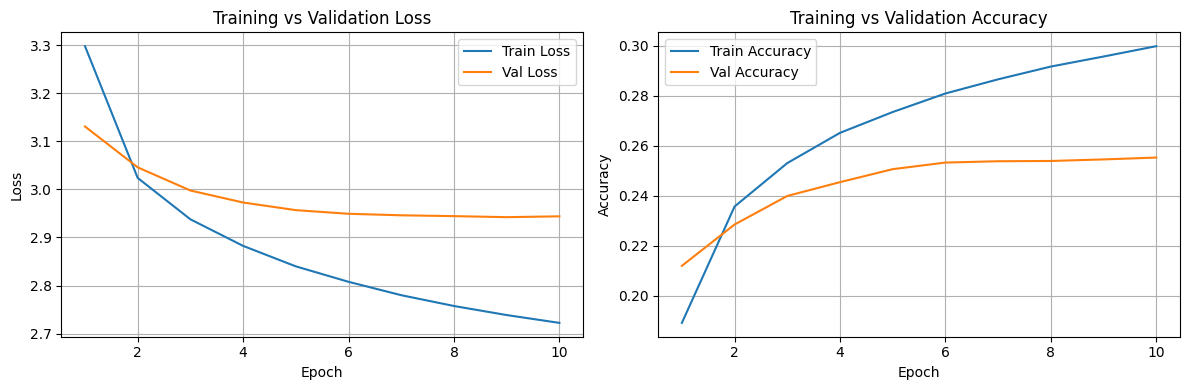

In [8]:
import matplotlib.pyplot as plt

epochs = range(1, len(train_losses) + 1)

plt.figure(figsize=(12, 4))

# Loss curves
plt.subplot(1, 2, 1)
plt.plot(epochs, train_losses, label="Train Loss")
plt.plot(epochs, val_losses, label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid(True)

# Accuracy curves
plt.subplot(1, 2, 2)
plt.plot(epochs, train_accuracies, label="Train Accuracy")
plt.plot(epochs, val_accuracies, label="Val Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


## 7. Save Final Model Checkpoint
Save trained model weights and metadata to the models/ directory.


In [ ]:
from pathlib import Path
import torch

BASE_DIR = Path.cwd().parent

CHECKPOINT_DIR = BASE_DIR / "models"
CHECKPOINT_DIR.mkdir(exist_ok=True)

MODEL_PATH = CHECKPOINT_DIR / "music_gru_checkpoint.pt"

checkpoint = {
    "state_dict": best_state_dict if best_state_dict is not None else model.state_dict(),
    "vocab_size": VOCAB_SIZE,
    "seq_len": SEQ_LEN,
    "embed_dim": model.embedding.embedding_dim,
    "hidden_dim": model.gru.hidden_size,
    "num_layers": model.gru.num_layers,
    "dropout": model.dropout_layer.p,
}

torch.save(checkpoint, MODEL_PATH)
print(f"Saved model checkpoint to {MODEL_PATH}")

Saved model checkpoint to /Users/catherinembata/music-generation-project/models/music_gru_checkpoint.pt


## 8. Model Evaluation on Test Set
Evaluate the trained GRU model on the held-out test set.


In [ ]:
if best_state_dict is not None:
    model.load_state_dict(best_state_dict)
    print("Loaded best model (by validation loss) for test evaluation.")

model.eval()
with torch.no_grad():
    test_loss, test_acc, test_ppl = run_epoch(
        test_loader, model, criterion, optimizer=None
    )

print(f"Test loss: {test_loss:.4f}")
print(f"Test accuracy: {test_acc:.4f}")
print(f"Test perplexity: {test_ppl:.4f}")

print(f"\nMajority baseline test accuracy:   {baseline_test_acc:.4f}")
print(f"Last-token baseline test accuracy: {last_test_acc:.4f}")

Loaded best model (by validation loss) for test evaluation.
Test loss: 2.8633
Test accuracy: 0.2781
Test perplexity: 17.5196

Majority baseline test accuracy:   0.0400
Last-token baseline test accuracy: 0.0415


## 9. Hyperparameter Tuning Function
A helper function for training and evaluating GRU models with different hyperparameters to support model comparison experiments.

In [11]:
def train_config(
    name,
    embed_dim=64,
    hidden_dim=128,
    num_layers=1,
    dropout=0.3,
    lr=1e-3,
    weight_decay=1e-5,
    num_epochs=6,
):
    """
    Train a new MusicGRUModel with the given hyperparameters.
    Uses the same train/val loaders and run_epoch function.
    Returns: (history_dict, best_val_acc)
    """
    print(f"\n=== Training config: {name} ===")
    print(f"embed_dim={embed_dim}, hidden_dim={hidden_dim}, "
          f"num_layers={num_layers}, dropout={dropout}, lr={lr}, "
          f"weight_decay={weight_decay}, epochs={num_epochs}")

    # Fresh model & optimizer for this config
    config_model = MusicGRUModel(
        vocab_size=VOCAB_SIZE,
        embed_dim=embed_dim,
        hidden_dim=hidden_dim,
        num_layers=num_layers,
        dropout=dropout,
    ).to(device)

    config_criterion = nn.CrossEntropyLoss()
    config_optimizer = torch.optim.Adam(
        config_model.parameters(), lr=lr, weight_decay=weight_decay
    )

    cfg_train_losses = []
    cfg_val_losses = []
    cfg_train_accuracies = []
    cfg_val_accuracies = []

    best_val_acc = 0.0

    for epoch in range(1, num_epochs + 1):
        start_time = time.time()

        train_loss, train_acc, train_ppl = run_epoch(
            train_loader, config_model, config_criterion, optimizer=config_optimizer
        )

        with torch.no_grad():
            val_loss, val_acc, val_ppl = run_epoch(
                val_loader, config_model, config_criterion, optimizer=None
            )

        cfg_train_losses.append(train_loss)
        cfg_val_losses.append(val_loss)
        cfg_train_accuracies.append(train_acc)
        cfg_val_accuracies.append(val_acc)

        if val_acc > best_val_acc:
            best_val_acc = val_acc

        elapsed = time.time() - start_time
        print(
            f"Epoch {epoch:02d}/{num_epochs} - {elapsed:.1f}s | "
            f"train_loss: {train_loss:.4f}, train_acc: {train_acc:.4f}, train_perplexity: {train_ppl:.4f} | "
            f"val_loss: {val_loss:.4f}, val_acc: {val_acc:.4f}, val_perplexity: {val_ppl:.4f} | "
        )

    history = {
        "train_losses": cfg_train_losses,
        "val_losses": cfg_val_losses,
        "train_accuracies": cfg_train_accuracies,
        "val_accuracies": cfg_val_accuracies,
    }

    print(f"Best val accuracy for {name}: {best_val_acc:.4f}")
    return history, best_val_acc


## 10. Hyperparameter Tuning Experiments
Compare performance across multiple model sizes or configurations.


In [ ]:
# Hyperparameter experiments: small vs bigger GRU

history_small, best_val_acc_small = train_config(
    name="small_GRU",
    embed_dim=64,
    hidden_dim=128,
    num_layers=1,
    dropout=0.3,
    lr=1e-3,
    num_epochs=6,
)

history_big, best_val_acc_big = train_config(
    name="bigger_GRU",
    embed_dim=128,
    hidden_dim=256,
    num_layers=1,
    dropout=0.3,
    lr=1e-3,
    num_epochs=6,
)

print("\nSummary of hyperparameter configs:")
print(f"  small_GRU  best val acc: {best_val_acc_small:.4f}")
print(f"  bigger_GRU best val acc: {best_val_acc_big:.4f}")
print(f"\nMajority baseline val accuracy:   {baseline_val_acc:.4f}")
print(f"Last-token baseline val accuracy: {last_val_acc:.4f}")


=== Training config: small_GRU ===
embed_dim=64, hidden_dim=128, num_layers=1, dropout=0.3, lr=0.001, weight_decay=1e-05, epochs=6
Epoch 01/6 - 87.2s | train_loss: 3.3828, train_acc: 0.1740, train_perplexity: 29.4530 | val_loss: 3.2008, val_acc: 0.1967, val_perplexity: 24.5514 | 
Epoch 02/6 - 89.7s | train_loss: 3.1094, train_acc: 0.2172, train_perplexity: 22.4066 | val_loss: 3.0976, val_acc: 0.2181, val_perplexity: 22.1436 | 
Epoch 03/6 - 88.7s | train_loss: 3.0314, train_acc: 0.2331, train_perplexity: 20.7255 | val_loss: 3.0486, val_acc: 0.2305, val_perplexity: 21.0861 | 
Epoch 04/6 - 86.9s | train_loss: 2.9854, train_acc: 0.2420, train_perplexity: 19.7936 | val_loss: 3.0189, val_acc: 0.2340, val_perplexity: 20.4695 | 
Epoch 05/6 - 85.8s | train_loss: 2.9517, train_acc: 0.2498, train_perplexity: 19.1383 | val_loss: 3.0002, val_acc: 0.2392, val_perplexity: 20.0902 | 
Epoch 06/6 - 89.0s | train_loss: 2.9245, train_acc: 0.2555, train_perplexity: 18.6252 | val_loss: 2.9843, val_acc: 0.2

## Training Summary

Training results showed that both GRU models significantly outperformed simple majority-token and last-token baselines, confirming that the model learned meaningful predictive structure in the data.

Between the two configurations tested, the larger GRU achieved consistently better validation metrics—including lower loss, lower perplexity, and higher accuracy—indicating that increased model capacity improves next-token prediction performance on this dataset.
